In [1]:
import numpy as np
import matplotlib.pyplot as pl
import scanpy as sc

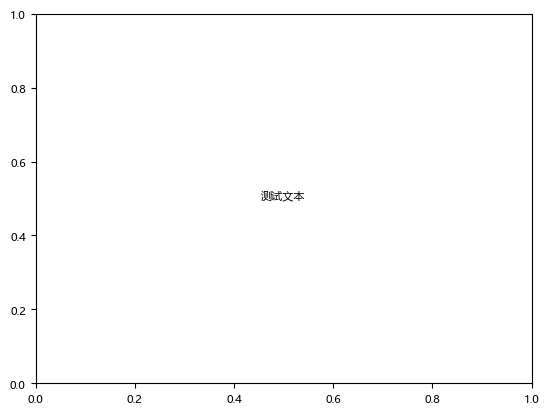

In [2]:
# 设置 Matplotlib 配置
pl.rcParams['font.family'] = 'Microsoft YaHei'  # 使用加载的字体
# pl.rcParams['font.weight'] = 'bold'            # 字体加粗
pl.rcParams['font.size'] = 8                  # 字体大小设置为 12

# 测试字体设置是否成功
pl.text(0.5, 0.5, '测试文本', fontsize=8,  ha='center')
pl.show()

In [3]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
results_file = "./write/paul15.h5ad"
# low dpi (dots per inch) yields small inline figures
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

C:\Users\Jack\PycharmProjects\local\venv\lib\site-packages\session_info\main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


-----
anndata     0.10.9
scanpy      1.10.3
-----
PIL                         10.1.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        24.2.0
attrs                       24.2.0
babel                       2.16.0
certifi                     2024.08.30
cffi                        1.17.1
chardet                     5.2.0
charset_normalizer          3.4.0
colorama                    0.4.6
comm                        0.2.2
cycler                      0.12.1
cython_runtime              NA
dateutil                    2.8.2
debugpy                     1.8.8
decorator                   5.1.1
defusedxml                  0.7.1
exceptiongroup              1.2.2
executing                   2.1.0
fastjsonschema              NA
fqdn                        NA
h5py                        3.12.1
idna                        3.10
igraph                      0.11.8
importlib_resources         NA
ipykernel                   6.29.5
iso

In [4]:
adata = sc.datasets.paul15()

In [5]:
adata

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

In [6]:
# this is not required and results will be comparable without it
adata.X = adata.X.astype("float64")

Preprocessing and Visualization

In [7]:
sc.pp.recipe_zheng17(adata)

running recipe zheng17
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
    finished (0:00:00)


In [8]:
sc.tl.pca(adata, svd_solver="arpack")

computing PCA
    with n_comps=50
    finished (0:00:00)


In [10]:
sc.pp.neighbors(adata, n_neighbors=4, n_pcs=20)
sc.tl.draw_graph(adata)

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:19)


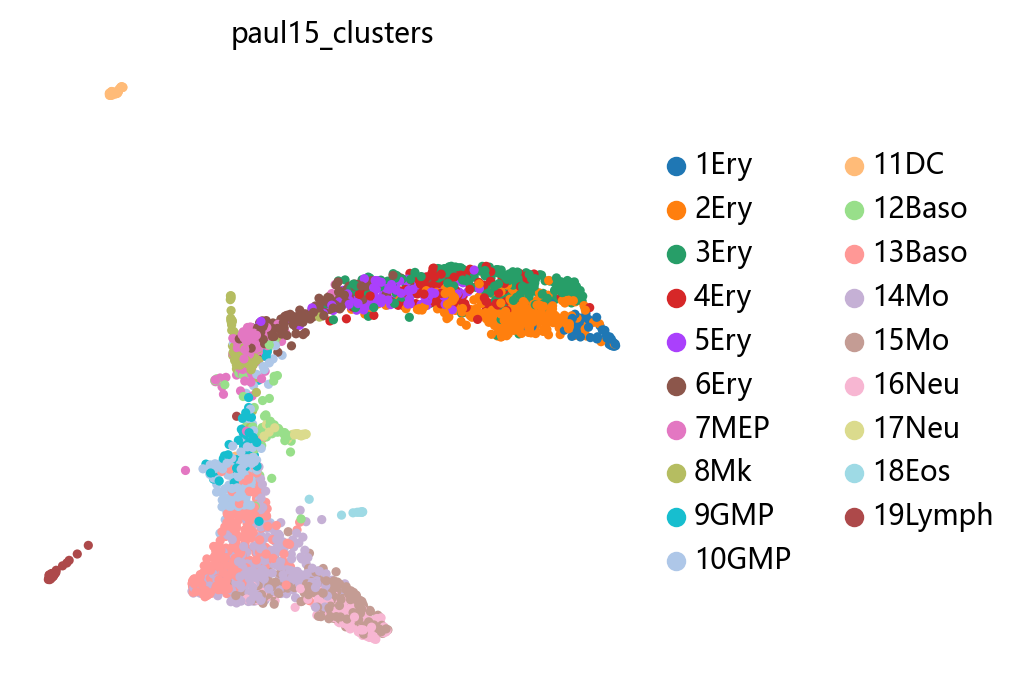

In [11]:
sc.set_figure_params(fontsize=10, dpi=100, frameon=False)
sc.pl.draw_graph(
    adata, 
    color="paul15_clusters", 
    legend_fontsize=10,  # 设置图例字体大小
)

Optional: Denoising the graph

In [12]:
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_diffmap")

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         1.         0.9989278  0.99671    0.99430376 0.98939794
     0.9883687  0.98731077 0.98398703 0.983007   0.9790806  0.9762548
     0.9744365  0.9729161  0.9652972 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [13]:
sc.tl.draw_graph(adata)

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:16)


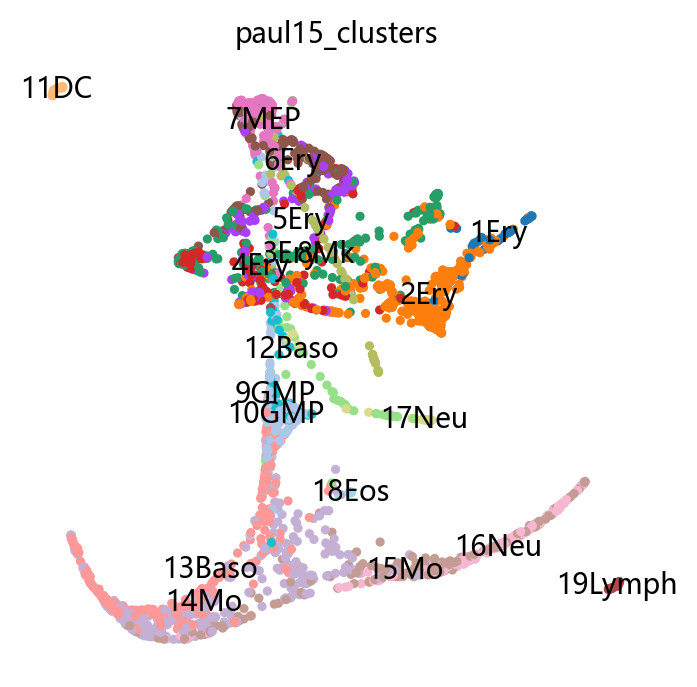

In [14]:
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

Clustering and PAGA

In [15]:
sc.tl.louvain(adata, resolution=1.0)

running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 25 clusters and added
    'louvain', the cluster labels (adata.obs, categorical) (0:00:00)


In [16]:
sc.tl.paga(adata, groups="louvain")

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


--> added 'pos', the PAGA positions (adata.uns['paga'])


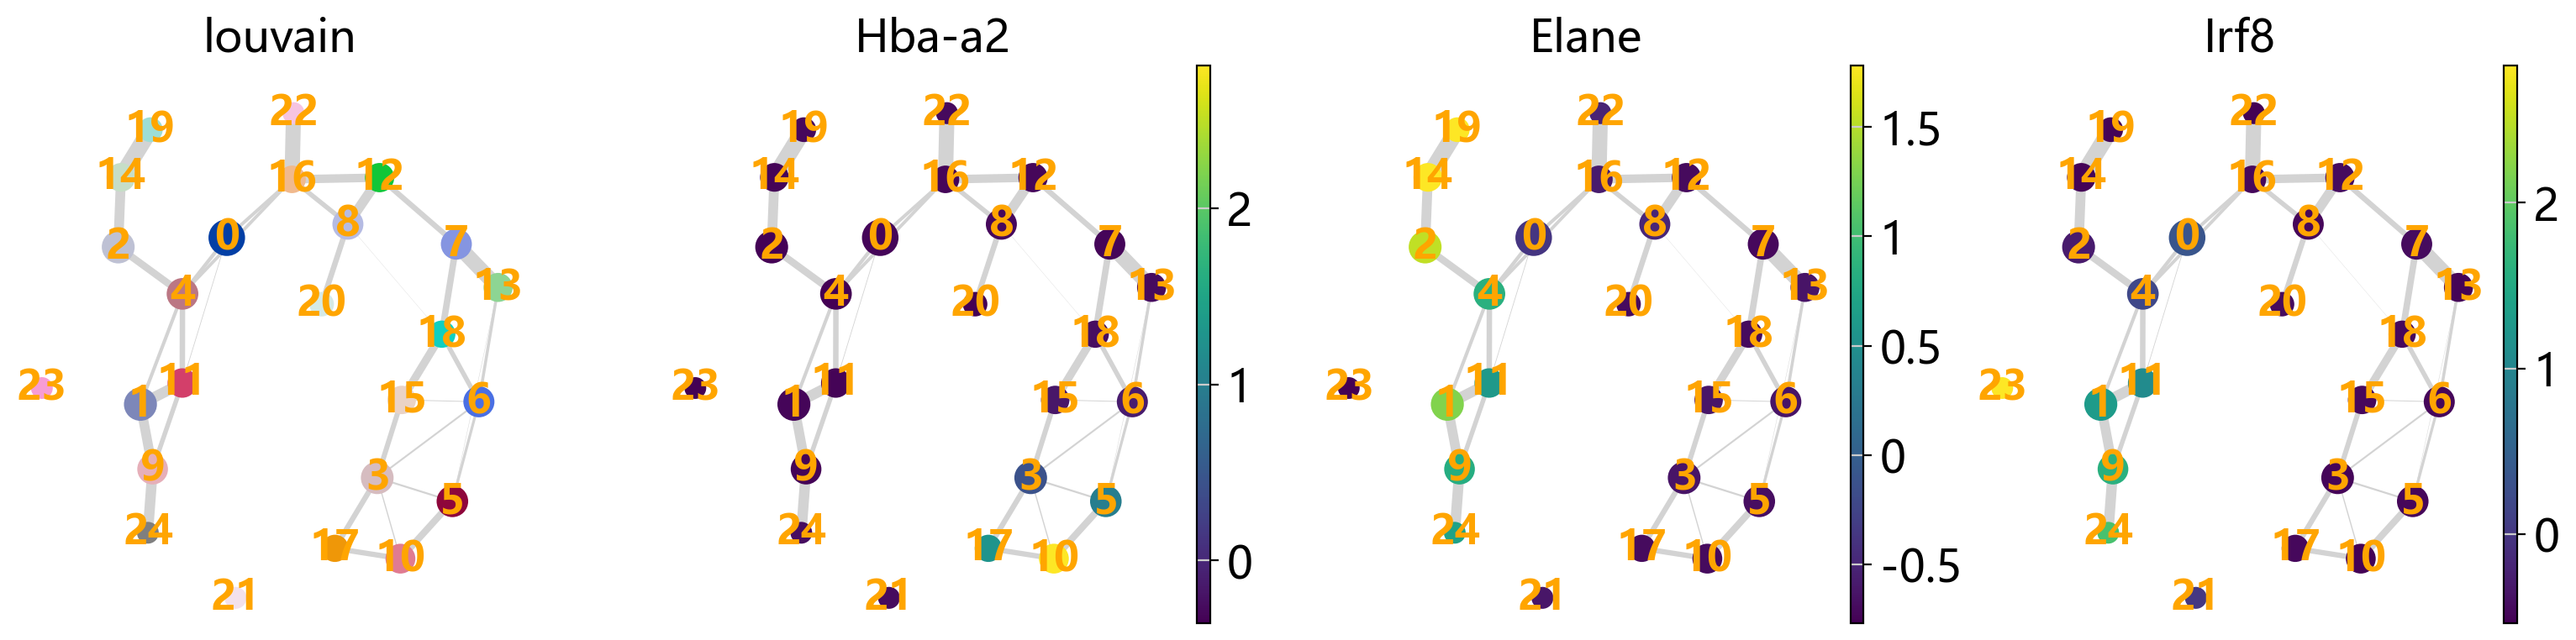

In [17]:
sc.set_figure_params(fontsize=19, dpi=100, frameon=False)
sc.pl.paga(adata, color=["louvain", "Hba-a2", "Elane", "Irf8"],text_kwds={"color": "orange"})

--> added 'pos', the PAGA positions (adata.uns['paga'])


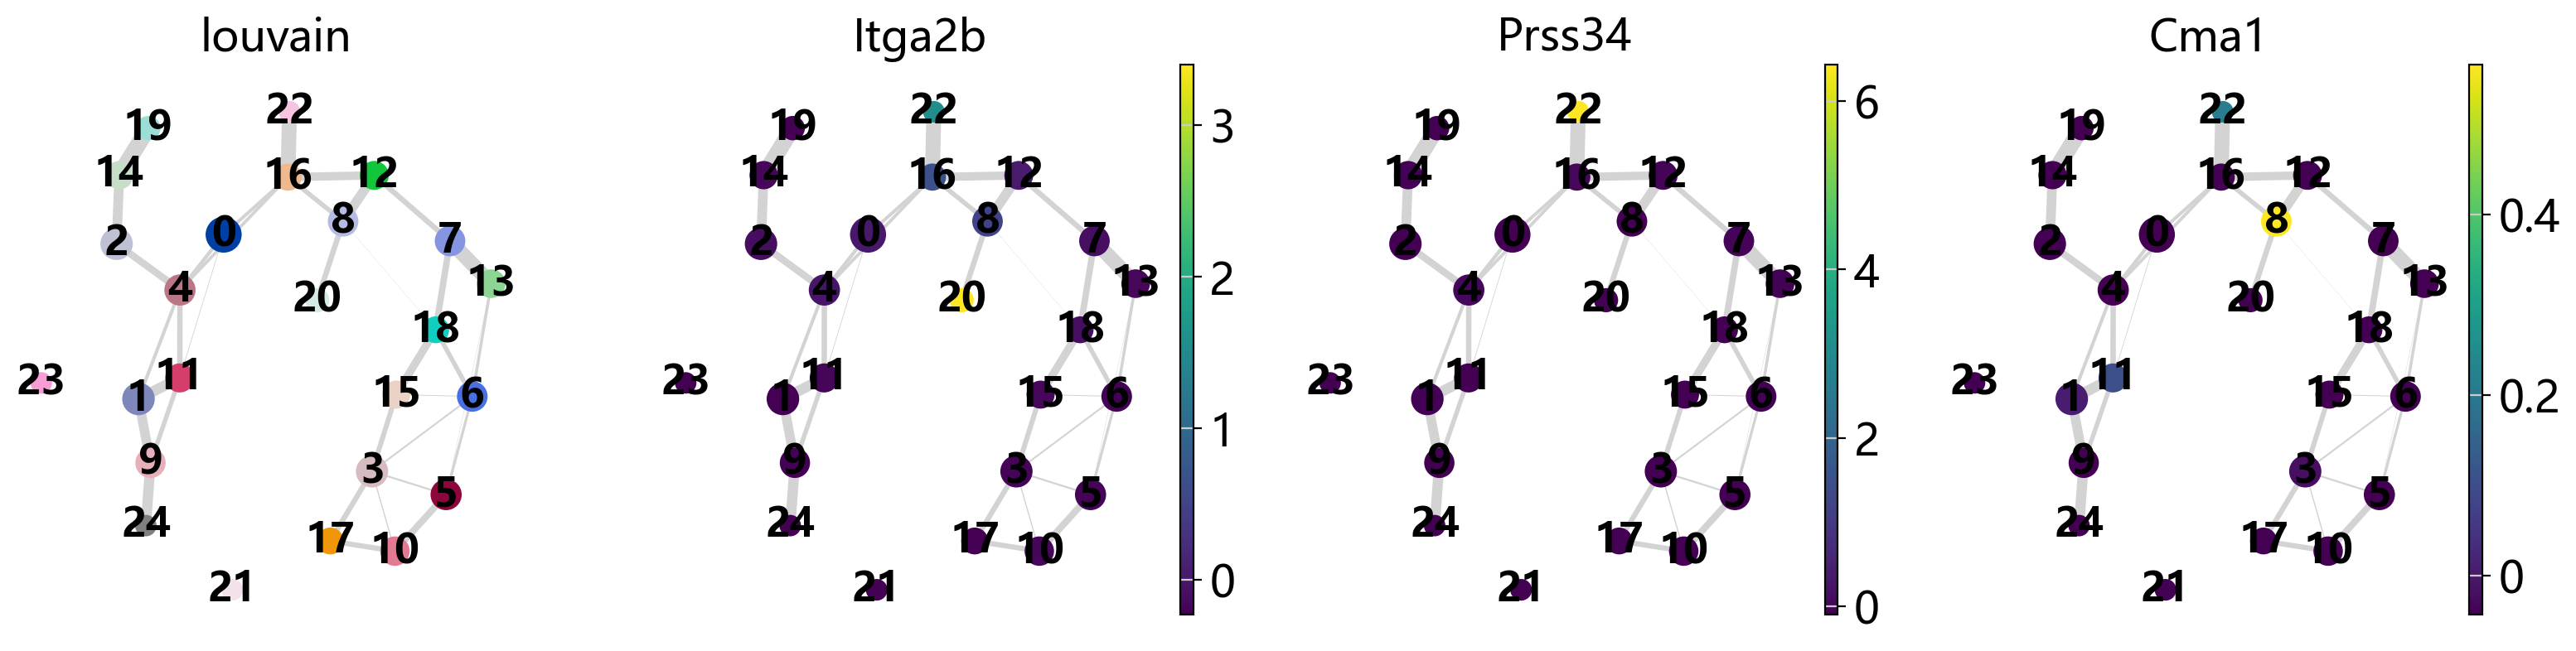

In [18]:
sc.pl.paga(adata, color=["louvain", "Itga2b", "Prss34", "Cma1"])

In [19]:
adata.obs["louvain"].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24'],
      dtype='object')

In [20]:
adata.obs["louvain_anno"] = adata.obs["louvain"]

In [21]:
sc.tl.paga(adata, groups="louvain_anno")

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


--> added 'pos', the PAGA positions (adata.uns['paga'])


<Axes: >

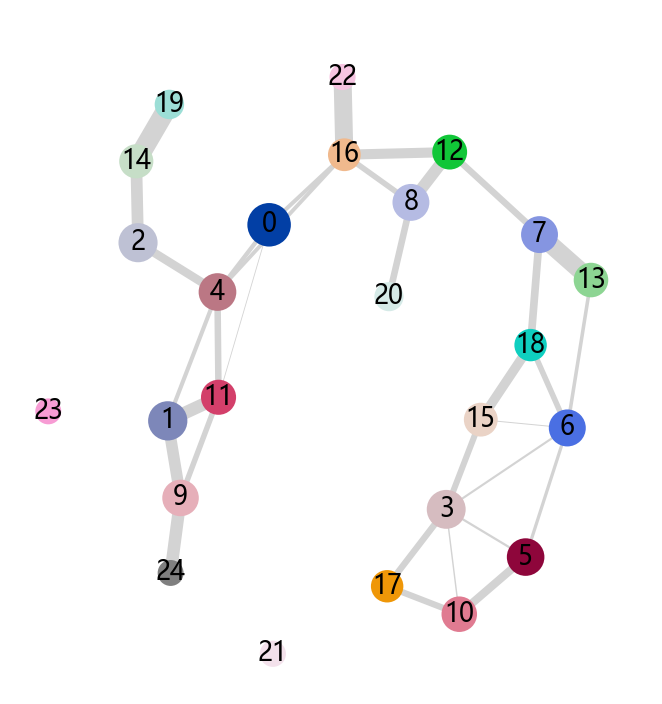

In [22]:
sc.set_figure_params(fontsize=10, dpi=100, frameon=False)
sc.pl.paga(adata, threshold=0.03, show=False,fontweight="normal",text_kwds={"color": "black"})

Recomputing the embedding using PAGA-initialization

In [23]:
sc.tl.draw_graph(adata, init_pos="paga")

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:16)


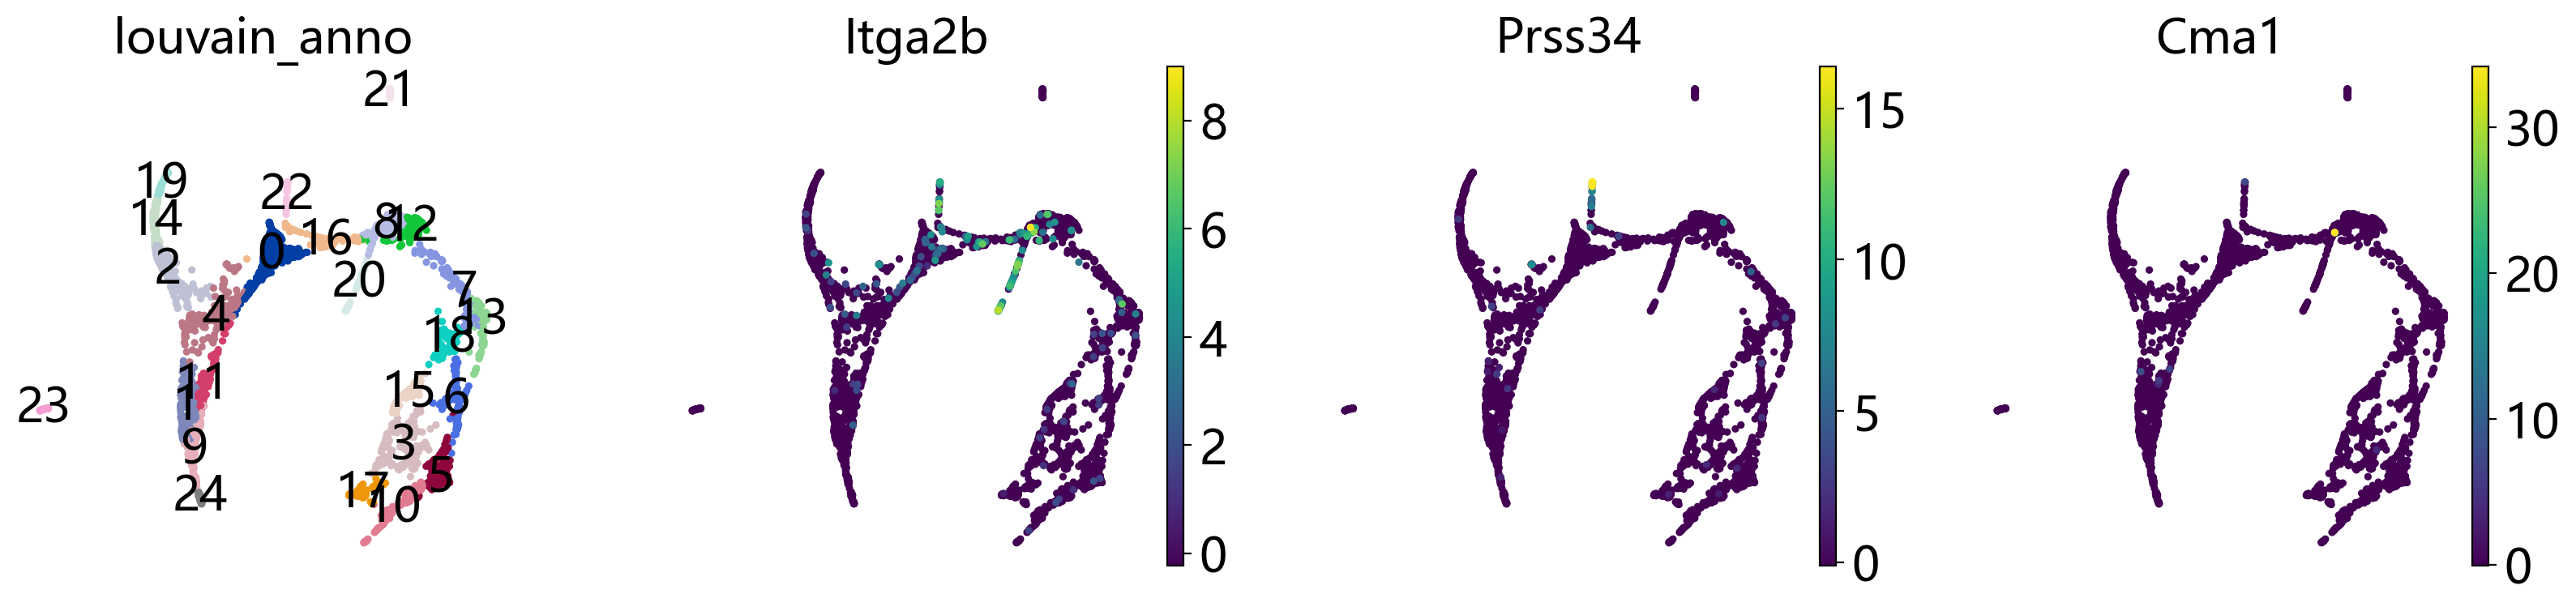

In [24]:
sc.set_figure_params(fontsize=21, dpi=100, frameon=False)
sc.pl.draw_graph(
    adata, color=["louvain_anno", "Itga2b", "Prss34", "Cma1"], legend_loc="on data"
)

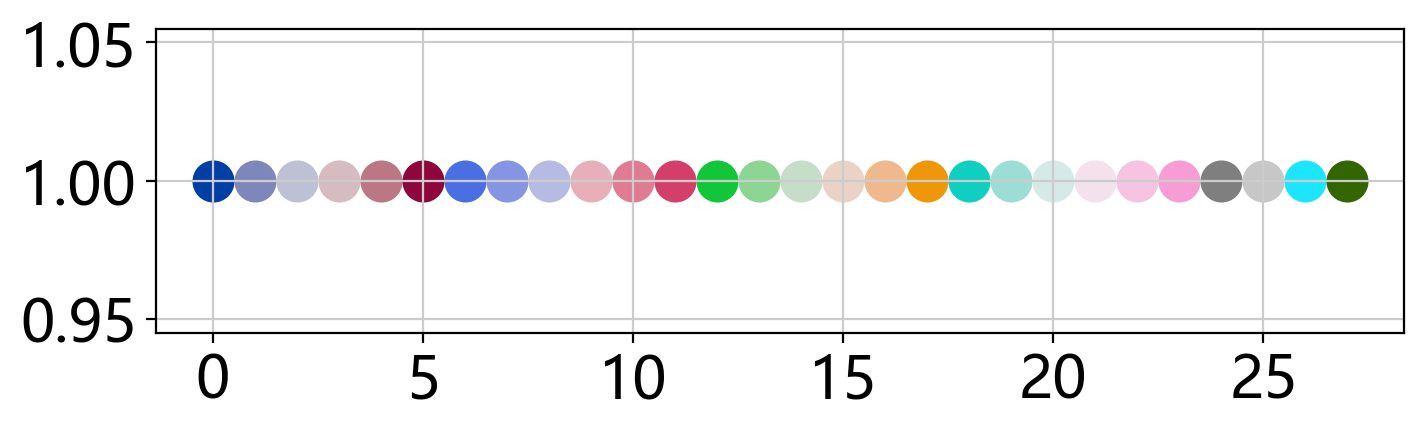

In [25]:
pl.figure(figsize=(8, 2))
for i in range(28):
    pl.scatter(i, 1, c=sc.pl.palettes.zeileis_28[i], s=200)
pl.show()

In [26]:
zeileis_colors = np.array(sc.pl.palettes.zeileis_28)
new_colors = np.array(adata.uns["louvain_anno_colors"])

In [27]:
new_colors = np.resize(new_colors, 25)
new_colors[[16]] = zeileis_colors[[12]]  # Stem colors / green
new_colors[[10, 17, 5, 3, 15, 6, 18, 13, 7, 12]] = zeileis_colors[  # Ery colors / red
    [5, 5, 5, 5, 11, 11, 10, 9, 21, 21]
]
new_colors[[20, 8]] = zeileis_colors[[17, 16]]  # Mk early Ery colors / yellow
new_colors[[4, 0]] = zeileis_colors[[2, 8]]  # lymph progenitors / grey
new_colors[[22]] = zeileis_colors[[18]]  # Baso / turquoise
new_colors[[19, 14, 2]] = zeileis_colors[[6, 6, 6]]  # Neu / light blue
new_colors[[24, 9, 1, 11]] = zeileis_colors[[0, 0, 0, 0]]  # Mo / dark blue
new_colors[[21, 23]] = zeileis_colors[[25, 25]]  # outliers / grey

In [28]:
adata.uns["louvain_anno_colors"] = new_colors

--> added 'pos', the PAGA positions (adata.uns['paga'])


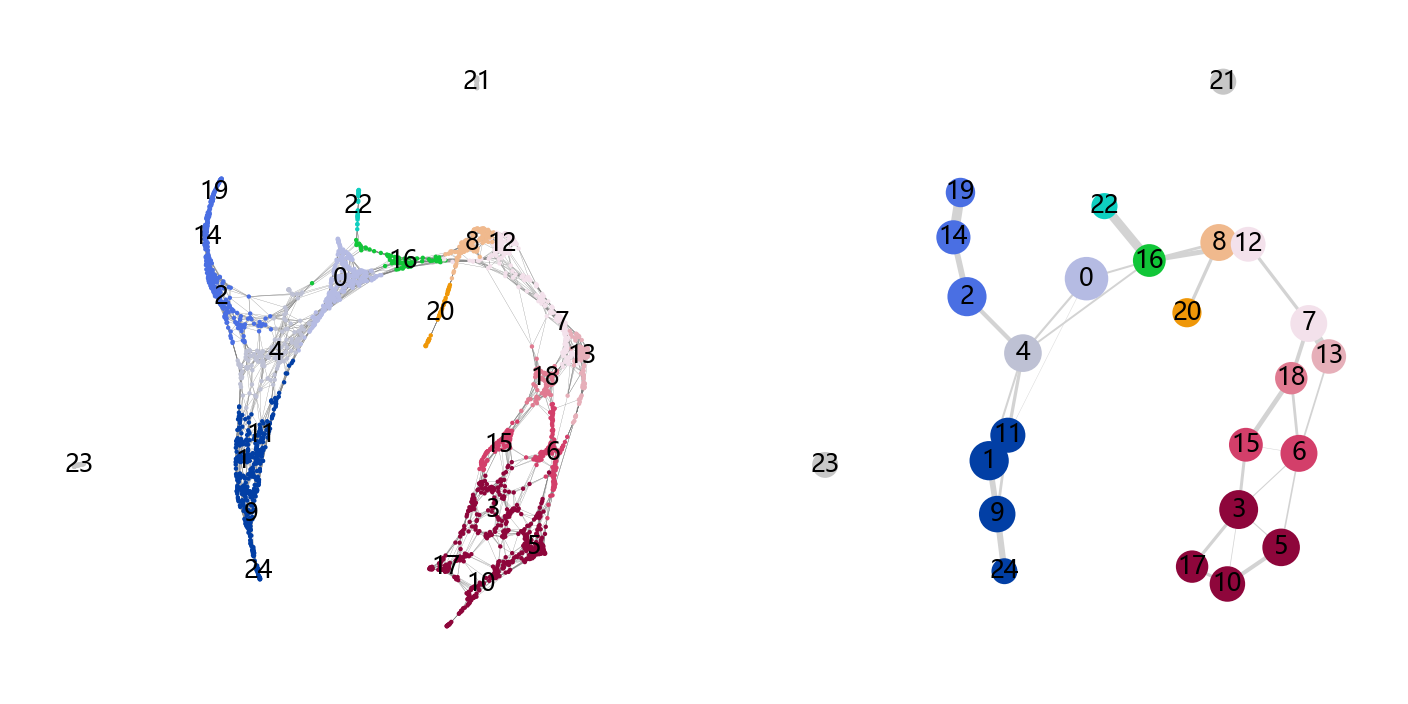

[<Axes: xlabel='FA1', ylabel='FA2'>, <Axes: >]

In [29]:
#sc.set_figure_params(fontsize=21, dpi=100, frameon=False)
sc.pl.paga_compare(
    adata,
    threshold=0.03,
    title="",
    right_margin=0.2,
    size=10,
    edge_width_scale=0.5,
    legend_fontsize=9,
    fontsize=10,
    frameon=False,
    edges=True,
    save=True,
    legend_fontweight="normal",
)

Reconstructing gene changes along PAGA paths for a given set of genes

In [30]:
adata.uns["iroot"] = np.flatnonzero(adata.obs["louvain_anno"] == "6")[0]


In [31]:
sc.tl.dpt(adata)

computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


In [32]:
gene_names = [
    *["Gata2", "Gata1", "Klf1", "Epor", "Hba-a2"],  # erythroid
    *["Elane", "Cebpe", "Gfi1"],  # neutrophil
    *["Irf8", "Csf1r", "Ctsg"],  # monocyte
]

In [33]:
adata_raw = sc.datasets.paul15()
sc.pp.log1p(adata_raw)
sc.pp.scale(adata_raw)
adata.raw = adata_raw

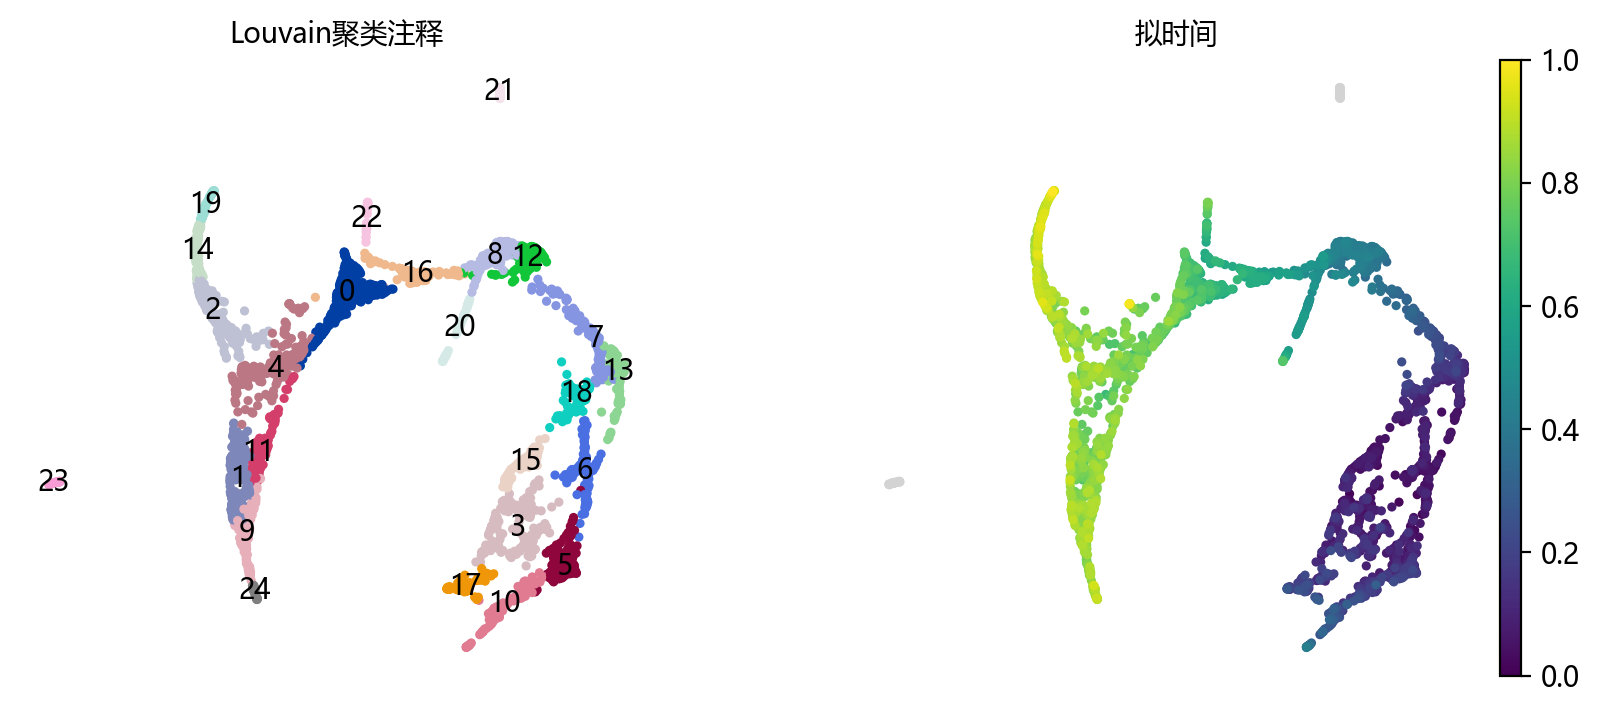

In [34]:
sc.set_figure_params(fontsize=10, dpi=100, frameon=False)
# 创建新的列名并赋值中文标签
adata.obs["Louvain聚类注释"] = adata.obs["louvain_anno"]
adata.obs["拟时间"] = adata.obs["dpt_pseudotime"]

# 使用新的中文列名绘图
sc.pl.draw_graph(adata, color=["Louvain聚类注释", "拟时间"],legend_fontsize=10, legend_loc="on data")

In [35]:
paths = [
    ("红细胞", [16, 12, 7, 13, 18, 6, 5, 10]),
    ("中性粒细胞", [16, 0, 4, 2, 14, 19]),
    ("单核细胞", [16, 0, 4, 11, 1, 9, 24]),
]

In [36]:
adata.obs["distance"] = adata.obs["dpt_pseudotime"]

In [37]:
adata.obs["clusters"] = adata.obs["louvain_anno"]  # just a cosmetic change

In [38]:
adata.uns["clusters_colors"] = adata.uns["louvain_anno_colors"]

In [39]:
!mkdir write

子目录或文件 write 已经存在。


C:\Users\Jack\PycharmProjects\local\venv\lib\site-packages\scanpy\plotting\_tools\paga.py:1283: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  groups_axis.set_yticklabels(["", xlabel, ""], fontsize=ytick_fontsize)
C:\Users\Jack\PycharmProjects\local\venv\lib\site-packages\scanpy\plotting\_tools\paga.py:1332: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  anno_axis.set_yticklabels(["", anno, ""], fontsize=ytick_fontsize)


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


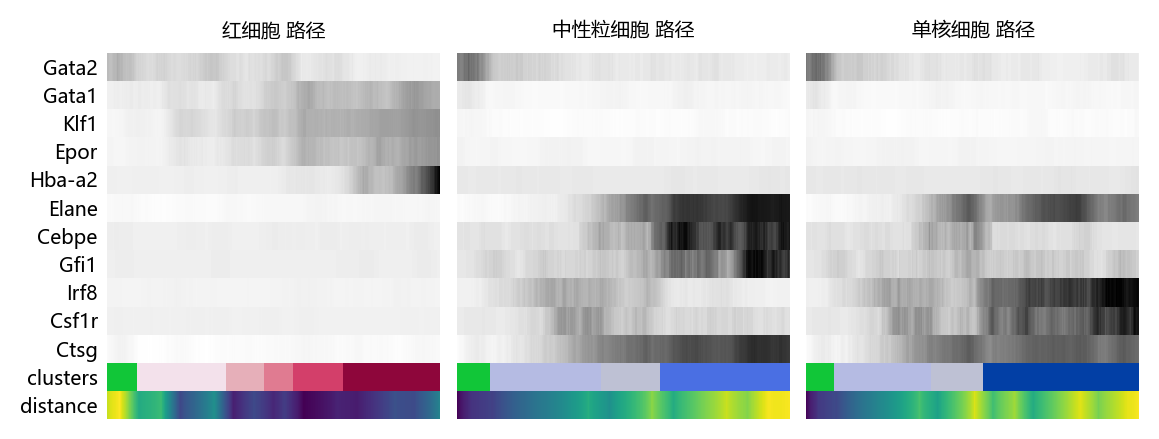

In [40]:
sc.set_figure_params(fontsize=10, dpi=100, frameon=False)
_, axs = pl.subplots(
    ncols=3, figsize=(6, 2.5), gridspec_kw={"wspace": 0.05, "left": 0.12}
)
pl.subplots_adjust(left=0.05, right=0.98, top=0.82, bottom=0.2)

for ipath, (descr, path) in enumerate(paths):
    result = sc.pl.paga_path(
        adata,
        path,
        gene_names,
        show_node_names=False,
        ax=axs[ipath],
        ytick_fontsize=7,
        title_fontsize=7,
        left_margin=0.15,
        n_avg=50,
        annotations=["distance"],
        show_yticks=True if ipath == 0 else False,
        show_colorbar=False,
        color_map="Greys",
        groups_key="clusters",
        color_maps_annotations={"distance": "viridis"},
        title="{} 路径".format(descr),
        return_data=True,
        show=False,
    )

    # 打印返回值类型
    print(type(result))  # 应该是 <class 'pandas.core.frame.DataFrame'>

    # 保存数据
    result.to_csv(f"./write/paga_path_{descr}.csv")

# 保存图像
pl.savefig("./figures/paga_path_paul15.pdf")
pl.show()
